In [ ]:
# 1. Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MultiLabelBinarizer
import scipy.sparse as sp


In [14]:
#import RCV1 dataset
from sklearn.datasets import fetch_rcv1

# Load the RCV1 dataset
rcv1 = fetch_rcv1()

X = rcv1.data
y = rcv1.target

In [16]:
# Optional: use a smaller subset to save time
subset_size = 10000  # adjust for your system
X = X[:subset_size]
y = y[:subset_size]

In [20]:
from sklearn.svm import LinearSVC
# Convert to dense arrays for algorithms that require it
X_dense = X.toarray()
y_dense = y.toarray()

# For simplicity, convert multi-label to single-label by taking the first active label
y_single = np.argmax(y_dense, axis=1)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_dense, y_single, test_size=0.2, random_state=42)

# Define classifiers
models = {
    "Naive Bayes (BernoulliNB)": BernoulliNB(),
    "SVM (LinearSVC)": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}


Training Naive Bayes (BernoulliNB)...

=== Naive Bayes (BernoulliNB) ===
Accuracy Score: 0.4555

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.03        58
           1       0.00      0.00      0.00        27
           2       0.00      0.00      0.00        76
           3       0.00      0.00      0.00        14
           4       0.32      0.97      0.49       386
           8       0.00      0.00      0.00         3
           9       0.80      0.05      0.10        75
          14       1.00      0.02      0.05        82
          18       0.00      0.00      0.00        55
          19       0.00      0.00      0.00         6
          20       0.00      0.00      0.00         2
          21       1.00      0.02      0.05        41
          22       0.00      0.00      0.00        57
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00        28
          30  

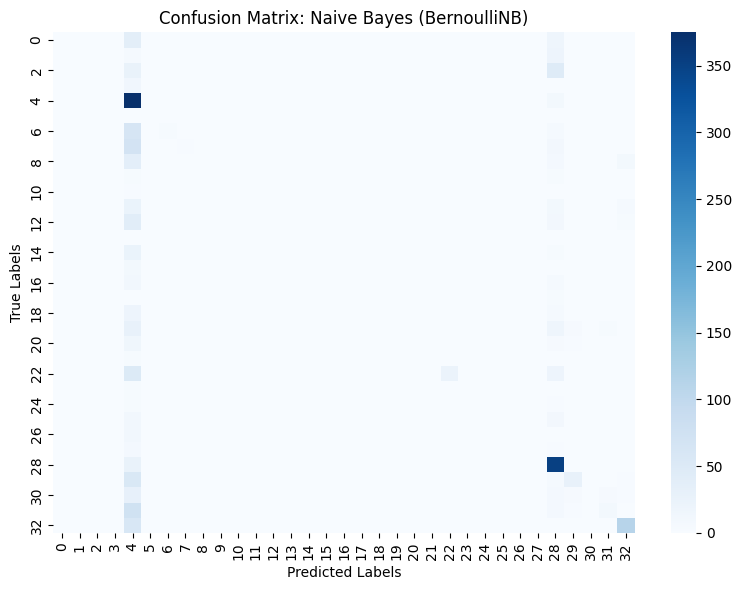


Training SVM (LinearSVC)...

=== SVM (LinearSVC) ===
Accuracy Score: 0.8060

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.26      0.33        58
           1       0.80      0.74      0.77        27
           2       0.53      0.50      0.51        76
           3       0.67      0.57      0.62        14
           4       0.92      0.94      0.93       386
           8       0.00      0.00      0.00         3
           9       0.79      0.71      0.75        75
          14       0.70      0.76      0.73        82
          18       0.58      0.60      0.59        55
          19       0.29      0.33      0.31         6
          20       0.00      0.00      0.00         2
          21       0.42      0.41      0.42        41
          22       0.63      0.39      0.48        57
          26       1.00      1.00      1.00         1
          27       0.68      0.54      0.60        28
          30       0.78      0.70 

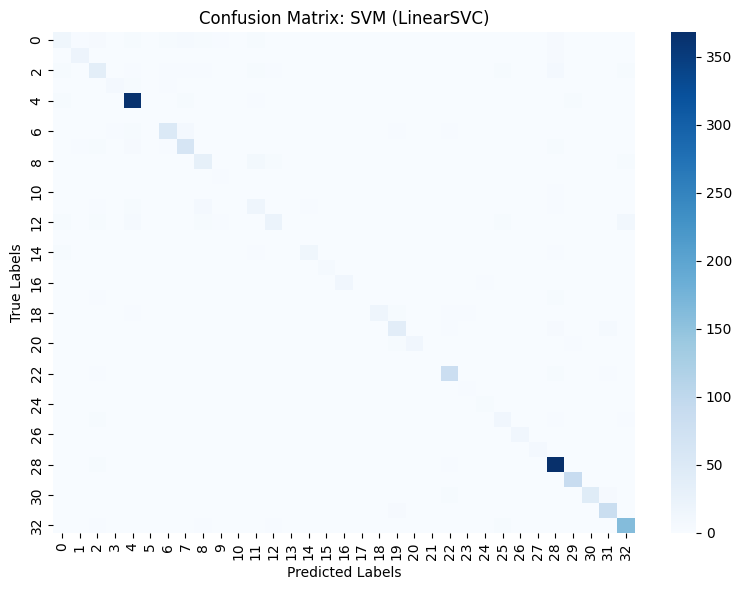


Training Random Forest...

=== Random Forest ===
Accuracy Score: 0.7170

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.12      0.19        58
           1       0.77      0.37      0.50        27
           2       0.47      0.12      0.19        76
           3       1.00      0.14      0.25        14
           4       0.71      0.96      0.81       386
           8       0.00      0.00      0.00         3
           9       0.91      0.56      0.69        75
          14       0.62      0.57      0.59        82
          18       0.65      0.36      0.47        55
          19       0.00      0.00      0.00         6
          20       0.00      0.00      0.00         2
          21       0.42      0.12      0.19        41
          22       0.67      0.21      0.32        57
          26       1.00      1.00      1.00         1
          27       0.75      0.21      0.33        28
          30       0.70      0.70     

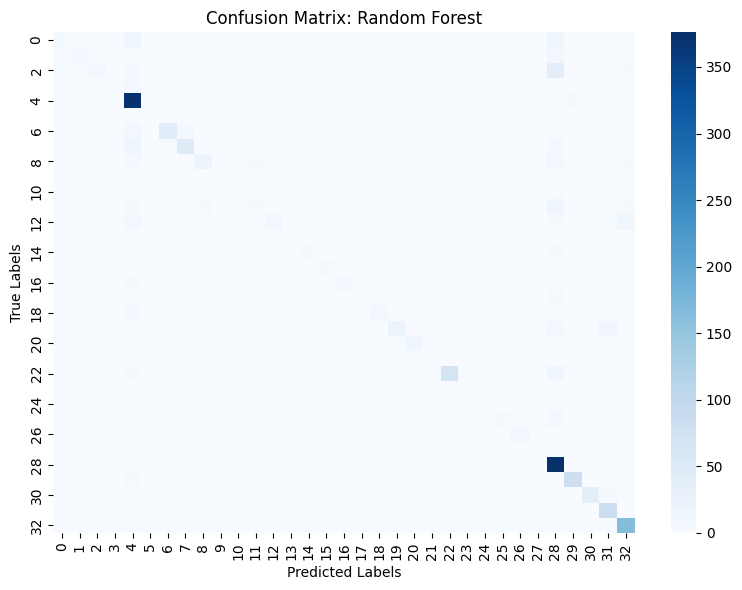

In [ ]:
#train each model to all classifiers

for name, model in models.items():
    print(f"\nTraining {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"Accuracy Score: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix (values):")
    print(cm)

    # Visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()